In [6]:
import sys
!{sys.executable} -m pip install torc

In [7]:
from torc import RoundCoil, Container, Z

print("TORC installed!")

TORC installed!


========== Target Field ==========
Slower length L = 0.619 m
B at oven entrance = 296.79 G
B near 3D MOT = 0.00 G
Maximum field = 296.79 G
Minimum field = 0.00 G


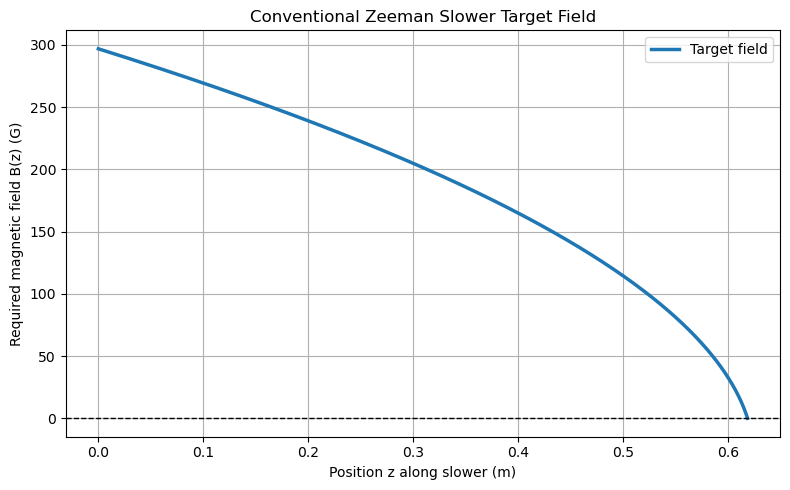

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

from torc import RoundCoil, Container, Z, cm, gauss

os.makedirs("figures", exist_ok=True)

# ============================================================
# Step 1: Target field for conventional Zeeman slower
# High field at oven entrance -> near 0 G at 3D MOT
# ============================================================

lambda_He = 1083e-9      # m
mu_eff_over_h = 1.4      # MHz/G
delta = -250.0           # MHz

vi = 500.0               # m/s
vf = 50.0                # m/s
a = 2.0e5                # m/s^2

L = (vi**2 - vf**2) / (2*a)

z = np.linspace(0, L, 1500)
v = np.sqrt(vi**2 - 2*a*z)

doppler_MHz = (v / lambda_He) / 1e6

# Raw resonance field
B_raw_G = -(delta + doppler_MHz) / mu_eff_over_h

# Shift profile so MOT end is approximately 0 G
B_target_G = B_raw_G[-1] - B_raw_G

print("========== Target Field ==========")
print(f"Slower length L = {L:.3f} m")
print(f"B at oven entrance = {B_target_G[0]:.2f} G")
print(f"B near 3D MOT = {B_target_G[-1]:.2f} G")
print(f"Maximum field = {B_target_G.max():.2f} G")
print(f"Minimum field = {B_target_G.min():.2f} G")

plt.figure(figsize=(8, 5))
plt.plot(z, B_target_G, linewidth=2.5, label="Target field")
plt.axhline(0, color="k", linestyle="--", linewidth=1)

plt.xlabel("Position z along slower (m)")
plt.ylabel("Required magnetic field B(z) (G)")
plt.title("Conventional Zeeman Slower Target Field")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("figures/torc_target_field_conventional.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# ============================================================
# Step 2: Preliminary conventional Zeeman slower coil
# ============================================================

from torc import RoundCoil, Container, Z, cm, gauss

coils = Container()

R_inner = 2.5 * cm
R_outer = 3.0 * cm

N_sections = 25

section_edges = np.linspace(0, L, N_sections + 1)
section_centers = 0.5 * (section_edges[:-1] + section_edges[1:])
section_width = L / N_sections

# More turns where the target field is larger
B_interp = np.interp(section_centers, z, B_target_G)

B_norm = B_interp / np.max(B_interp)

min_turns = 2
max_turns = 80

turns = min_turns + (max_turns - min_turns) * B_norm
turns = np.round(turns).astype(int)

for i, (zc, Nt) in enumerate(zip(section_centers, turns)):

    coils.add(
        RoundCoil(
            r0=(0, 0, zc),
            n=Z,
            inner_radius=R_inner,
            outer_radius=R_outer,
            height=0.9 * section_width,
            num_turns=int(Nt),
            name=f"coil_{i}",
        )
    )

print("Number of coil sections:", len(turns))
print("Turns per section:")
print(turns)

Number of coil sections: 25
Turns per section:
[80 78 76 75 73 71 69 67 65 62 60 58 56 53 50 48 45 42 39 35 31 27 22 16
  8]


========== TORC Coil Field ==========
Best-fit current = 7.44 A
Coil field at oven entrance = 148.61 G
Coil field near 3D MOT = 22.82 G
Coil field max = 274.96 G
Coil field min = 22.82 G


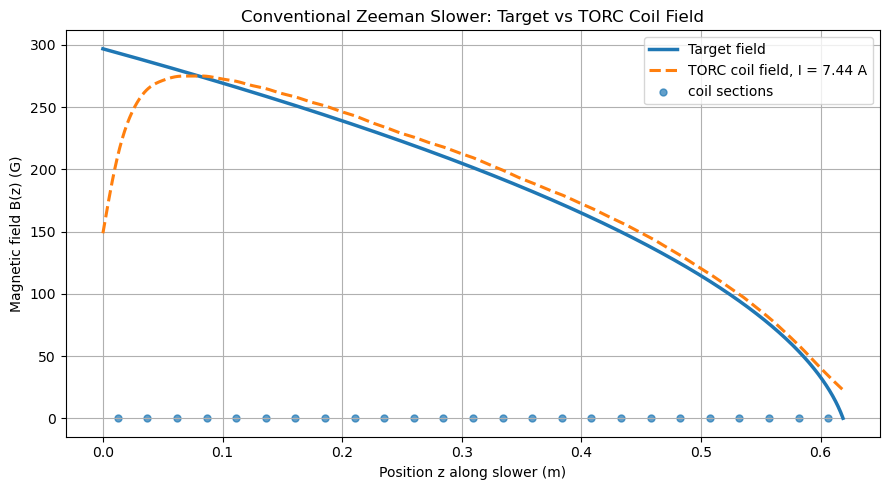

In [10]:
# ============================================================
# Step 3: Calculate TORC coil field and compare with target
# ============================================================

B = coils.B((0, 0, z), I=1.0)
Bx, By, Bz = B

# Convert Tesla to Gauss
B_coil_1A_G = Bz / gauss

# Best-fit current scale
scale = np.dot(B_target_G, B_coil_1A_G) / np.dot(B_coil_1A_G, B_coil_1A_G)

I_required = scale
B_coil_G = scale * B_coil_1A_G

print("========== TORC Coil Field ==========")
print(f"Best-fit current = {I_required:.2f} A")
print(f"Coil field at oven entrance = {B_coil_G[0]:.2f} G")
print(f"Coil field near 3D MOT = {B_coil_G[-1]:.2f} G")
print(f"Coil field max = {B_coil_G.max():.2f} G")
print(f"Coil field min = {B_coil_G.min():.2f} G")

plt.figure(figsize=(9, 5))

plt.plot(z, B_target_G, linewidth=2.5, label="Target field")
plt.plot(
    z,
    B_coil_G,
    "--",
    linewidth=2.2,
    label=f"TORC coil field, I = {I_required:.2f} A"
)

plt.scatter(
    section_centers,
    np.zeros_like(section_centers),
    s=25,
    alpha=0.7,
    label="coil sections"
)

plt.xlabel("Position z along slower (m)")
plt.ylabel("Magnetic field B(z) (G)")
plt.title("Conventional Zeeman Slower: Target vs TORC Coil Field")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/torc_conventional_target_vs_coil.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# ============================================================
# Step 4: Compare different numbers of coil sections
# ============================================================

def build_torc_coils(N_sections, R_inner=2.5*cm, R_outer=3.0*cm,
                     min_turns=2, max_turns=80):
    coils = Container()

    section_edges = np.linspace(0, L, N_sections + 1)
    section_centers = 0.5 * (section_edges[:-1] + section_edges[1:])
    section_width = L / N_sections

    B_interp = np.interp(section_centers, z, B_target_G)
    B_norm = B_interp / np.max(B_interp)

    turns = min_turns + (max_turns - min_turns) * B_norm
    turns = np.round(turns).astype(int)

    for i, (zc, Nt) in enumerate(zip(section_centers, turns)):
        coils.add(
            RoundCoil(
                r0=(0, 0, zc),
                n=Z,
                inner_radius=R_inner,
                outer_radius=R_outer,
                height=0.9 * section_width,
                num_turns=int(Nt),
                name=f"coil_{i}",
            )
        )

    return coils, section_centers, turns


def evaluate_geometry(N_sections):
    coils, section_centers, turns = build_torc_coils(N_sections)

    B = coils.B((0, 0, z), I=1.0)
    Bx, By, Bz = B

    B_coil_1A_G = Bz / gauss

    scale = np.dot(B_target_G, B_coil_1A_G) / np.dot(B_coil_1A_G, B_coil_1A_G)

    I_required = scale
    B_coil_G = scale * B_coil_1A_G

    error = B_coil_G - B_target_G

    rms_error = np.sqrt(np.mean(error**2))
    max_abs_error = np.max(np.abs(error))

    return {
        "N_sections": N_sections,
        "I_required": I_required,
        "rms_error": rms_error,
        "max_abs_error": max_abs_error,
        "B_coil_G": B_coil_G,
        "error": error,
        "section_centers": section_centers,
        "turns": turns,
    }


section_list = [5, 8, 10, 12, 15, 20, 25, 30, 35, 40]

results = []

for N in section_list:
    result = evaluate_geometry(N)
    results.append(result)

    print(
        f"N = {N:2d} | "
        f"I = {result['I_required']:.2f} A | "
        f"RMS error = {result['rms_error']:.2f} G | "
        f"Max error = {result['max_abs_error']:.2f} G"
    )

N =  5 | I = 35.10 A | RMS error = 28.93 G | Max error = 175.22 G
N =  8 | I = 22.59 A | RMS error = 22.61 G | Max error = 159.69 G
N = 10 | I = 18.37 A | RMS error = 20.95 G | Max error = 154.10 G
N = 12 | I = 15.33 A | RMS error = 20.64 G | Max error = 151.98 G
N = 15 | I = 12.31 A | RMS error = 20.41 G | Max error = 149.98 G
N = 20 | I = 9.29 A | RMS error = 20.40 G | Max error = 148.37 G
N = 25 | I = 7.44 A | RMS error = 20.52 G | Max error = 148.18 G
N = 30 | I = 6.23 A | RMS error = 20.25 G | Max error = 147.36 G
N = 35 | I = 5.34 A | RMS error = 20.49 G | Max error = 147.66 G
N = 40 | I = 4.68 A | RMS error = 20.40 G | Max error = 147.54 G


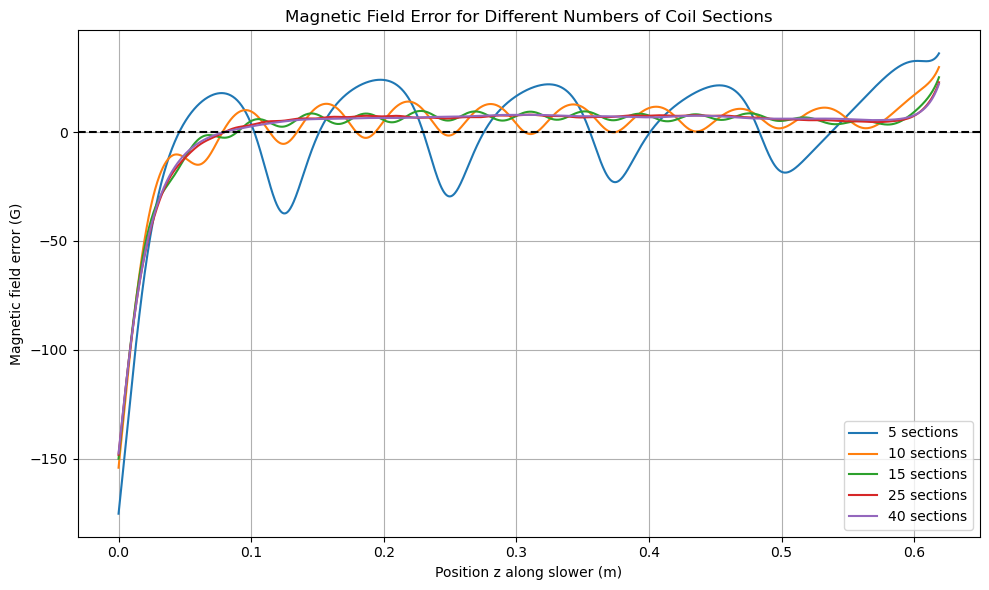

In [16]:
plt.figure(figsize=(10,6))

for N in [5, 10, 15, 25, 40]:
    r = evaluate_geometry(N)
    plt.plot(z, r["error"], label=f"{N} sections")

plt.axhline(0, color="k", ls="--")
plt.xlabel("Position z along slower (m)")
plt.ylabel("Magnetic field error (G)")
plt.title("Magnetic Field Error for Different Numbers of Coil Sections")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figures/torc_error_vs_sections.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Compare RMS error excluding edge regions

z_min = 0.03   # exclude first 3 cm
z_max = L - 0.03   # exclude last 3 cm

mask = (z > z_min) & (z < z_max)

print("RMS error excluding first/last 3 cm:")
for r in results:
    rms_mid = np.sqrt(np.mean(r["error"][mask]**2))
    max_mid = np.max(np.abs(r["error"][mask]))

    print(
        f"N = {r['N_sections']:2d} | "
        f"RMS mid = {rms_mid:.2f} G | "
        f"Max mid = {max_mid:.2f} G"
    )

RMS error excluding first/last 3 cm:
N =  5 | RMS mid = 17.11 G | Max mid = 37.38 G
N =  8 | RMS mid = 9.98 G | Max mid = 21.30 G
N = 10 | RMS mid = 8.17 G | Max mid = 21.30 G
N = 12 | RMS mid = 7.99 G | Max mid = 26.16 G
N = 15 | RMS mid = 7.61 G | Max mid = 31.24 G
N = 20 | RMS mid = 7.50 G | Max mid = 32.43 G
N = 25 | RMS mid = 7.56 G | Max mid = 32.77 G
N = 30 | RMS mid = 7.23 G | Max mid = 31.04 G
N = 35 | RMS mid = 7.55 G | Max mid = 32.32 G
N = 40 | RMS mid = 7.38 G | Max mid = 31.79 G


In [14]:
# ============================================================
# Step 5: Grid search optimization of coil geometry
# ============================================================

def build_torc_coils_custom(
    N_sections=15,
    R_inner_cm=2.5,
    R_outer_cm=3.0,
    min_turns=2,
    max_turns=80,
    height_factor=0.9,
):
    coils = Container()

    R_inner = R_inner_cm * cm
    R_outer = R_outer_cm * cm

    section_edges = np.linspace(0, L, N_sections + 1)
    section_centers = 0.5 * (section_edges[:-1] + section_edges[1:])
    section_width = L / N_sections

    B_interp = np.interp(section_centers, z, B_target_G)
    B_norm = B_interp / np.max(B_interp)

    turns = min_turns + (max_turns - min_turns) * B_norm
    turns = np.round(turns).astype(int)

    for i, (zc, Nt) in enumerate(zip(section_centers, turns)):
        coils.add(
            RoundCoil(
                r0=(0, 0, zc),
                n=Z,
                inner_radius=R_inner,
                outer_radius=R_outer,
                height=height_factor * section_width,
                num_turns=int(Nt),
                name=f"coil_{i}",
            )
        )

    return coils, section_centers, turns


def evaluate_custom_geometry(
    N_sections=15,
    R_inner_cm=2.5,
    R_outer_cm=3.0,
    min_turns=2,
    max_turns=80,
    height_factor=0.9,
):
    coils, section_centers, turns = build_torc_coils_custom(
        N_sections=N_sections,
        R_inner_cm=R_inner_cm,
        R_outer_cm=R_outer_cm,
        min_turns=min_turns,
        max_turns=max_turns,
        height_factor=height_factor,
    )

    B = coils.B((0, 0, z), I=1.0)
    Bx, By, Bz = B

    B_coil_1A_G = Bz / gauss

    scale = np.dot(B_target_G, B_coil_1A_G) / np.dot(B_coil_1A_G, B_coil_1A_G)

    I_required = scale
    B_coil_G = scale * B_coil_1A_G
    error = B_coil_G - B_target_G

    # Exclude first and last 3 cm
    mask = (z > 0.03) & (z < L - 0.03)

    rms_mid = np.sqrt(np.mean(error[mask]**2))
    max_mid = np.max(np.abs(error[mask]))

    return {
        "N_sections": N_sections,
        "R_inner_cm": R_inner_cm,
        "R_outer_cm": R_outer_cm,
        "min_turns": min_turns,
        "max_turns": max_turns,
        "height_factor": height_factor,
        "I_required": I_required,
        "rms_mid": rms_mid,
        "max_mid": max_mid,
        "B_coil_G": B_coil_G,
        "error": error,
        "turns": turns,
        "section_centers": section_centers,
    }


# ============================================================
# Parameter ranges to test
# ============================================================

N_sections_list = [12, 15, 20]
R_inner_list = [2.0, 2.5, 3.0]       # cm
coil_thickness_list = [0.3, 0.5, 0.8] # cm, so R_outer = R_inner + thickness
min_turns_list = [0, 2, 5]
max_turns_list = [60, 80, 100, 120]
height_factor_list = [0.7, 0.9, 1.1]

optimization_results = []

for N_sections in N_sections_list:
    for R_inner_cm in R_inner_list:
        for thickness_cm in coil_thickness_list:
            R_outer_cm = R_inner_cm + thickness_cm

            for min_turns in min_turns_list:
                for max_turns in max_turns_list:
                    for height_factor in height_factor_list:

                        result = evaluate_custom_geometry(
                            N_sections=N_sections,
                            R_inner_cm=R_inner_cm,
                            R_outer_cm=R_outer_cm,
                            min_turns=min_turns,
                            max_turns=max_turns,
                            height_factor=height_factor,
                        )

                        optimization_results.append(result)

# Sort by lowest mid-region RMS error
optimization_results = sorted(
    optimization_results,
    key=lambda r: r["rms_mid"]
)

best = optimization_results[0]

print("========== Best Geometry Found ==========")
print(f"N_sections   = {best['N_sections']}")
print(f"R_inner      = {best['R_inner_cm']:.2f} cm")
print(f"R_outer      = {best['R_outer_cm']:.2f} cm")
print(f"min_turns    = {best['min_turns']}")
print(f"max_turns    = {best['max_turns']}")
print(f"height factor= {best['height_factor']}")
print(f"I_required   = {best['I_required']:.2f} A")
print(f"RMS mid      = {best['rms_mid']:.2f} G")
print(f"Max mid      = {best['max_mid']:.2f} G")
print()
print("Turns:")
print(best["turns"])

========== Best Geometry Found ==========
N_sections   = 20
R_inner      = 2.00 cm
R_outer      = 2.30 cm
min_turns    = 0
max_turns    = 120
height factor= 0.9
I_required   = 6.19 A
RMS mid      = 5.10 G
Max mid      = 21.82 G

Turns:
[120 117 113 109 106 102  98  94  89  85  80  75  70  64  58  52  44  36
  26  12]


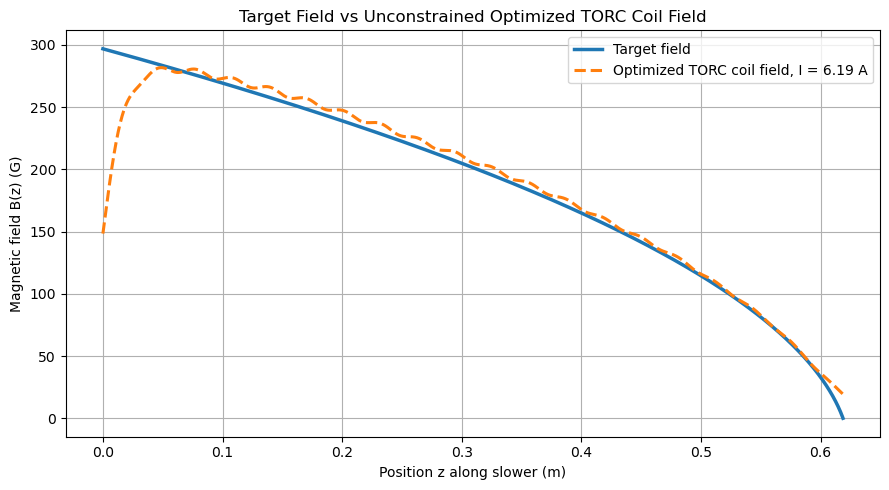

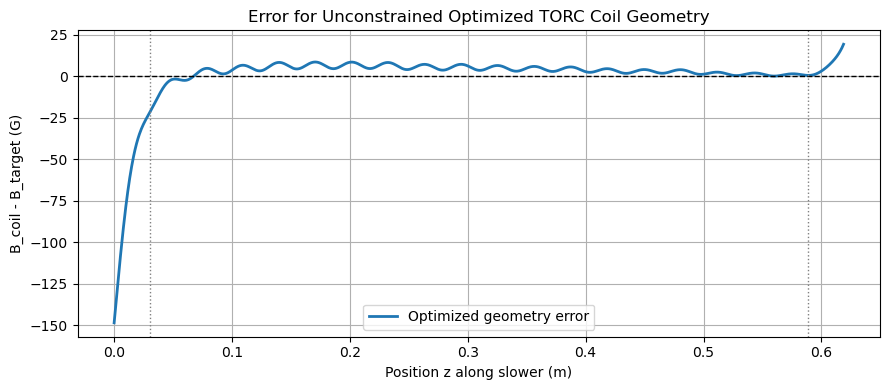

In [15]:
# ============================================================
# Plot best unconstrained optimized geometry vs target
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    z,
    B_target_G,
    linewidth=2.5,
    label="Target field"
)

plt.plot(
    z,
    best["B_coil_G"],
    "--",
    linewidth=2.2,
    label=f"Optimized TORC coil field, I = {best['I_required']:.2f} A"
)

plt.xlabel("Position z along slower (m)")
plt.ylabel("Magnetic field B(z) (G)")
plt.title("Target Field vs Unconstrained Optimized TORC Coil Field")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/torc_unconstrained_optimized_target_vs_coil.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Plot error for best unconstrained optimized geometry
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(
    z,
    best["error"],
    linewidth=2,
    label="Optimized geometry error"
)

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.axvline(0.03, color="gray", linestyle=":", linewidth=1)
plt.axvline(L - 0.03, color="gray", linestyle=":", linewidth=1)

plt.xlabel("Position z along slower (m)")
plt.ylabel("B_coil - B_target (G)")
plt.title("Error for Unconstrained Optimized TORC Coil Geometry")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/torc_unconstrained_optimized_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

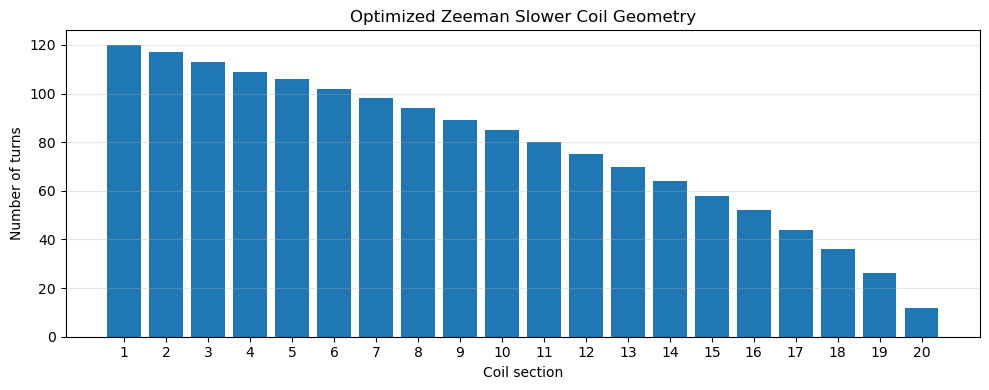

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Optimized turn distribution
turns = [120,117,113,109,106,102,98,94,89,85,
         80,75,70,64,58,52,44,36,26,12]

sections = np.arange(1, len(turns)+1)

plt.figure(figsize=(10,4))

plt.bar(sections, turns, width=0.8)

plt.xlabel("Coil section")
plt.ylabel("Number of turns")
plt.title("Optimized Zeeman Slower Coil Geometry")
plt.grid(axis="y", alpha=0.3)

plt.xticks(sections)

plt.tight_layout()

plt.savefig("figures/optimized_turn_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()